# Border-effect sanity checks: image mask vs. filtered-bin border

One row per sample, three columns, all in the same image/mask coordinates
(every 8um bin's position on the mask comes from
`bosperrus.quantify_diffusion_from_raw(..., return_data=True)`, so no
grid-vs-image orientation guessing is needed):

1. **Image + contours** -- the tissue image exactly as it was segmented (Visium
   hires H&E; STOmics ssDNA, downscaled), the image-only tissue mask used for
   the diffusion fit (lime, dashed), and the footprint of the filtered bins
   in qualifying components (pink).
2. **Filtered counts + border/elbow/BLADE** -- per-bin filtered counts, the
   footprint (pink), the bosperrus piecewise-linear elbow buffer (blue) and the
   BLADE buffer (orange), each fit per spatially-connected component.
3. **RAW counts outside the image mask** -- whole capture area (zero-count bins
   included), raw 8um bins outside the mask, i.e. exactly what the diffusion fit sees.

All numbers come from `src/utils/st_precompute.py` (compute node), stored in
`results/exploratory/st_reroll/`; this notebook only plots.

In [1]:
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import ndimage

from bosperrus import FIT_PALETTE

RESULTS_DIR = Path("../results/exploratory/st_reroll")  # written by src/utils/st_precompute.py
SAMPLES = pd.read_csv("../src/utils/st_samples.csv")

In [2]:
MARGIN_FRAC = 0.05             # column 1/2 crop margin around qualifying bins, fraction of their extent
BSPBLUE = FIT_PALETTE["Piecewise Linear Fit"]
BLADE_ORANGE = "orange"
IMAGE_MASK_COLOR = "#39FF14"   # lime
SPOT_MASK_COLOR = "#FF1493"    # deep pink

N_SAMPLES = len(SAMPLES)

In [3]:
def _pad_linear(a):
    """Pad a 2D coordinate array by one cell on every side, extrapolating linearly."""
    a = np.pad(a, 1, mode="edge").astype(float)
    a[0, :], a[-1, :] = 2 * a[1, :] - a[2, :], 2 * a[-2, :] - a[-3, :]
    a[:, 0], a[:, -1] = 2 * a[:, 1] - a[:, 2], 2 * a[:, -2] - a[:, -3]
    return a


def load_sample(sample):
    """Everything st_precompute.py wrote for one sample, plus the dense-grid
    mask coordinates of every bin: raw bins cover the full capture-area grid,
    so MASK_ROW[array_row, array_col] / MASK_COL[...] map any grid raster onto
    the image/mask -- contours drawn with these 2D coordinates land in image
    space directly, whatever the grid's orientation/rotation relative to the image."""
    npz = np.load(RESULTS_DIR / f"{sample}_diffusion_8um.npz")
    raw = {k: npz[k] for k in npz.files}
    filtered = pd.read_parquet(RESULTS_DIR / f"{sample}_filtered_bins.parquet")
    shape = (raw["array_row"].max() + 1, raw["array_col"].max() + 1)
    grid_row = np.full(shape, np.nan); grid_col = np.full(shape, np.nan)
    grid_row[raw["array_row"], raw["array_col"]] = raw["mask_row"]
    grid_col[raw["array_row"], raw["array_col"]] = raw["mask_col"]
    if np.isnan(grid_row).any():
        raise ValueError(f"{sample}: raw bins don't cover the full grid")
    return raw, filtered, _pad_linear(grid_row), _pad_linear(grid_col)


def grid_raster(shape, array_row, array_col, values):
    """Values on the (1-cell padded) capture-area grid, 0 elsewhere."""
    out = np.zeros((shape[0] + 2, shape[1] + 2))
    out[array_row + 1, array_col + 1] = values
    return out

## Build the figure, one row per sample

In [4]:
def process_sample_row(fig, axes_row, i):
    sample = SAMPLES["name"].iloc[i]
    dataset_type = SAMPLES["dataset_type"].iloc[i]
    print("reading", sample)
    raw, filtered, grid_row, grid_col = load_sample(sample)
    shape = (grid_row.shape[0] - 2, grid_row.shape[1] - 2)
    mask = raw["mask"]

    qual = filtered["components"].to_numpy() >= 0  # bins in a qualifying (>= MIN_COMPONENT_SPOTS) component
    q = filtered[qual]
    occupancy = grid_raster(shape, q["array_row"], q["array_col"], 1.0)
    bsp_grid = grid_raster(shape, q["array_row"], q["array_col"], q["analysis_buffer"].astype(float))
    blade_grid = grid_raster(shape, q["array_row"], q["array_col"], q["in_blade_buffer"].astype(float))

    # crop (columns 1 and 2) around the qualifying bins, in mask/image coordinates
    r0, r1 = q["mask_row"].min(), q["mask_row"].max()
    c0, c1 = q["mask_col"].min(), q["mask_col"].max()
    mr, mc = (r1 - r0) * MARGIN_FRAC, (c1 - c0) * MARGIN_FRAC
    crop_x, crop_y = (c0 - mc, c1 + mc), (r1 + mr, r0 - mr)  # y inverted: image orientation

    # === Column 1: image + image mask + spot footprint ===
    ax = axes_row[0]
    f = int(raw["image_factor"])
    img = raw["image"]
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None,
              extent=(-0.5, img.shape[1] * f - 0.5, img.shape[0] * f - 0.5, -0.5))
    # footprint first (solid), mask last (dashed, on top): where they coincide the
    # footprint still shows through the dash gaps
    ax.contour(grid_col, grid_row, occupancy, levels=[0.5], colors=[SPOT_MASK_COLOR], linewidths=1.2)
    ax.contour(np.arange(mask.shape[1]), np.arange(mask.shape[0]), mask.astype(float), levels=[0.5],
               colors=[IMAGE_MASK_COLOR], linewidths=1.8, linestyles="--")
    ax.set_xlim(*crop_x); ax.set_ylim(*crop_y)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{sample} ({dataset_type}): image + mask/spot contours", fontsize=9)
    if i == 0:
        ax.legend(handles=[
            Line2D([0], [0], color=IMAGE_MASK_COLOR, lw=1.8, ls="--", label="image mask (used for diffusion)"),
            Line2D([0], [0], color=SPOT_MASK_COLOR, lw=1.2, label="filtered-bin footprint"),
        ], loc="lower center", bbox_to_anchor=(0.5, 1.08), ncol=2, fontsize=8, frameon=False)

    # === Column 2: filtered counts + footprint + bosperrus elbow + BLADE ===
    ax = axes_row[1]
    ax.scatter(q["mask_col"], q["mask_row"], c=q["n_counts"], cmap="gray", s=1, alpha=0.5, rasterized=True)
    ax.contour(grid_col, grid_row, bsp_grid, levels=[0.5], colors=[BSPBLUE], linewidths=1.2)
    ax.contour(grid_col, grid_row, blade_grid, levels=[0.5], colors=[BLADE_ORANGE], linewidths=1.2)
    ax.contour(grid_col, grid_row, occupancy, levels=[0.5], colors=[SPOT_MASK_COLOR], linewidths=0.8)
    ax.set_xlim(*crop_x); ax.set_ylim(*crop_y)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{sample}: filtered counts + border/elbow/BLADE", fontsize=9)
    if i == 0:
        ax.legend(handles=[
            Line2D([0], [0], color=BSPBLUE, lw=1.5, label="bosperrus elbow"),
            Line2D([0], [0], color=BLADE_ORANGE, lw=1.5, label="BLADE threshold"),
            Line2D([0], [0], color=SPOT_MASK_COLOR, lw=1.5, label="filtered-bin footprint"),
        ], loc="lower center", bbox_to_anchor=(0.5, 1.08), ncol=3, fontsize=8, frameon=False)

    # === Column 3: RAW counts outside the image mask, whole capture area ===
    ax = axes_row[2]
    outside = raw["distance_um"] > 0
    counts_outside = np.full(shape, np.nan)
    counts_outside[raw["array_row"][outside], raw["array_col"][outside]] = raw["n_counts"][outside]
    vmax = np.percentile(raw["n_counts"][outside], 99)
    mesh = ax.pcolormesh(grid_col[1:-1, 1:-1], grid_row[1:-1, 1:-1], np.ma.masked_invalid(counts_outside),
                         cmap="viridis", vmin=0, vmax=vmax, shading="nearest", rasterized=True)
    ax.contour(np.arange(mask.shape[1]), np.arange(mask.shape[0]), mask.astype(float), levels=[0.5],
               colors=["black"], linewidths=0.8)
    fig.colorbar(mesh, ax=ax, shrink=0.6, pad=0.02, label="n_counts per 8um bin (raw, clipped at p99)")
    ax.set_ylim(np.nanmax(grid_row), np.nanmin(grid_row))
    ax.set_xlim(np.nanmin(grid_col), np.nanmax(grid_col))
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{sample}: RAW counts outside image mask (8um)", fontsize=9)

    del raw, filtered, grid_row, grid_col, mask
    gc.collect()

reading breast_cancer
reading pancreas
reading colon_cancer_ff
reading breast_cancer_tma
reading Pat1
reading Pat2
reading Pat3
reading Pat4
reading A02991D1
reading A02994C6
reading Y01087DD
reading Y01084J8


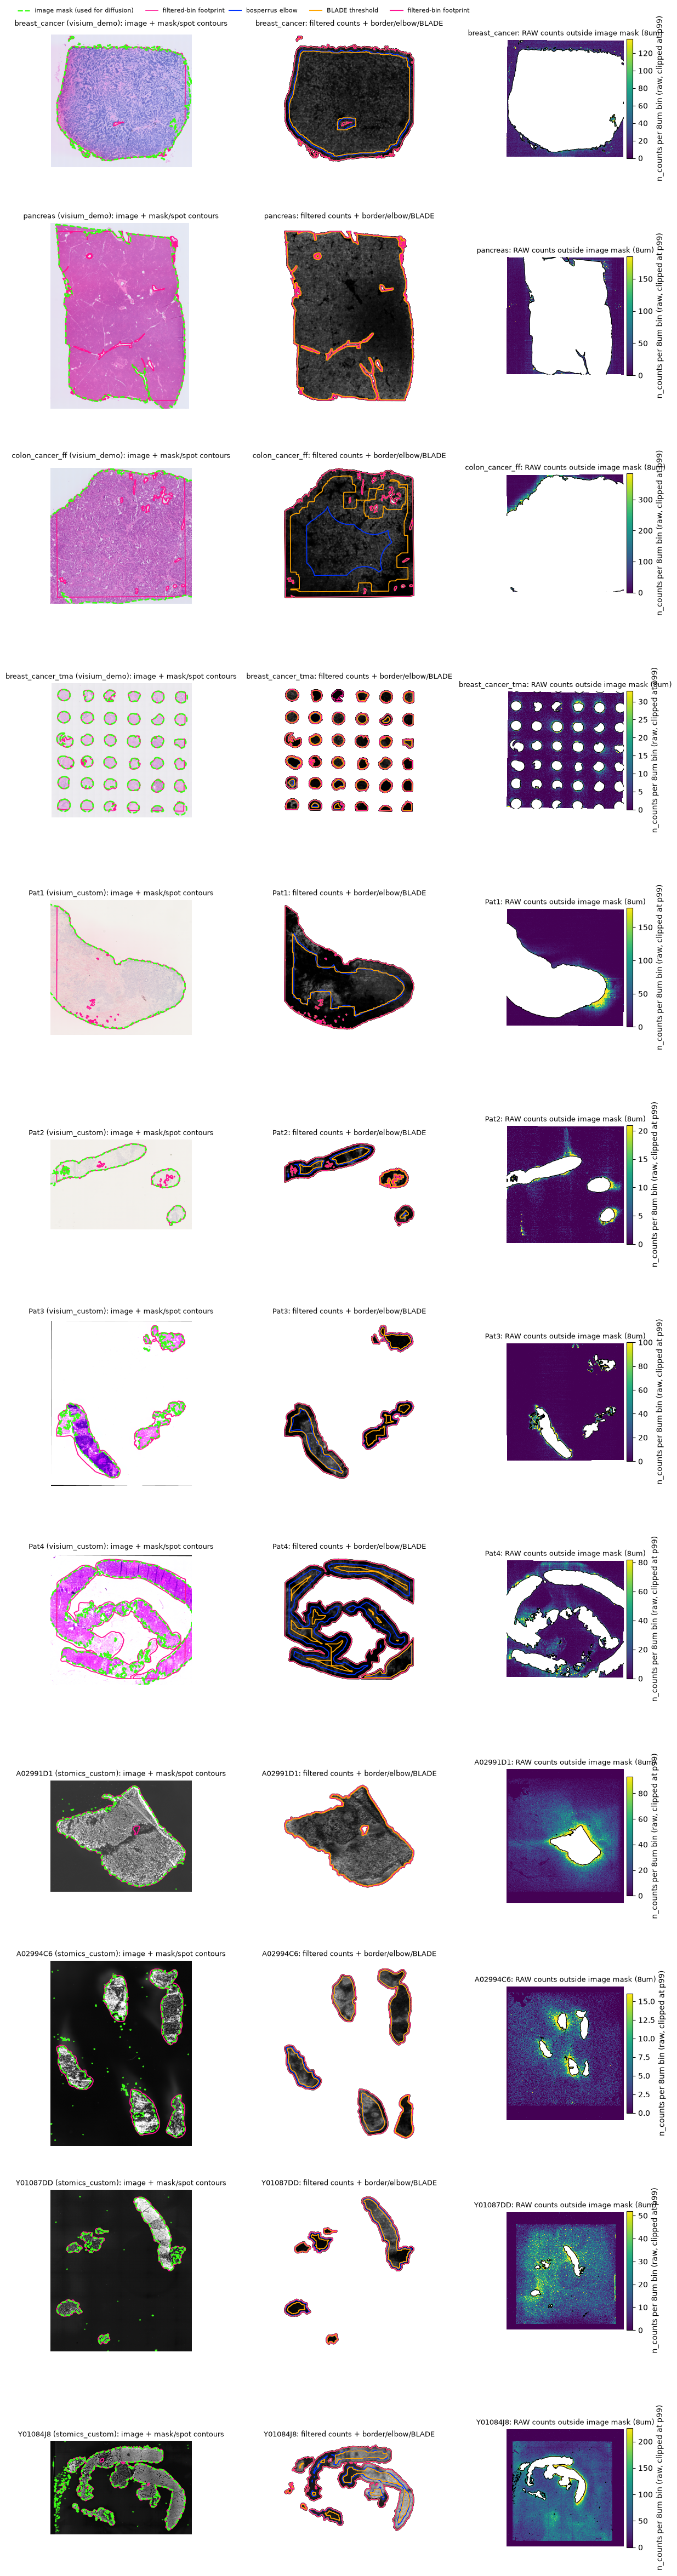

In [5]:
fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
for i in range(N_SAMPLES):
    process_sample_row(fig, axes[i], i)
plt.tight_layout()
plt.show()